##**House Price Prediction**

##**Problem Statement**
The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


In [2]:
data=pd.read_csv('Housing.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [9]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [4]:
#Handle Missing Values
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**There are no null values**

In [5]:
# Remove Duplicate Records
data.duplicated().sum()

np.int64(0)

**There are no duplicates**

##**EDA**
**Univariate Analysis**
*   Histogram
*   Countplot
*  Boxplot





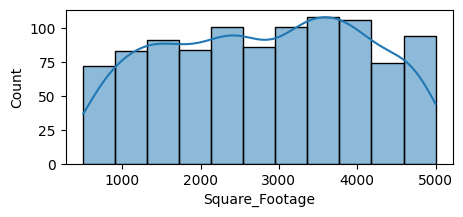

In [16]:
#Histogram for Square_Footage
plt.figure(figsize=(5,2))
sns.histplot(data,x='Square_Footage',kde=True)
plt.show()

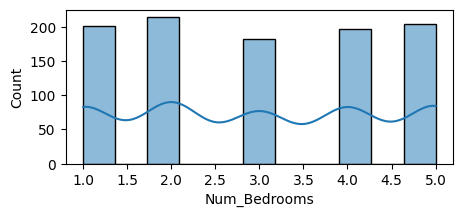

In [17]:
#Histogram for Num_bedrooms
plt.figure(figsize=(5,2))
sns.histplot(data,x='Num_Bedrooms',kde=True)
plt.show()

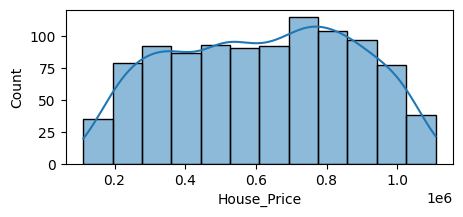

In [18]:
#Histogram for House_Price
plt.figure(figsize=(5,2))
sns.histplot(data,x='House_Price',kde=True)
plt.show()

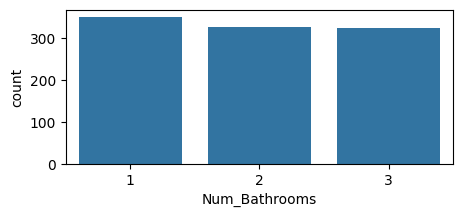

In [19]:
#Countplot for Num_Bathrooms
plt.figure(figsize=(5,2))
sns.countplot(data,x='Num_Bathrooms')
plt.show()

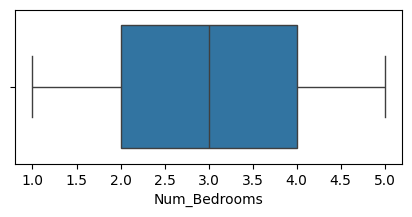

In [20]:
#Boxplot for Num_Bedrooms
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Num_Bedrooms')
plt.show()

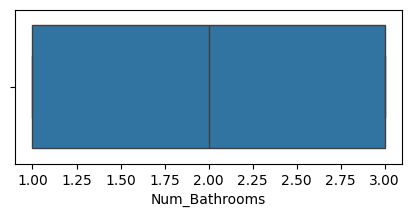

In [21]:
#Boxplot for Num_Bathrooms
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Num_Bathrooms')
plt.show()

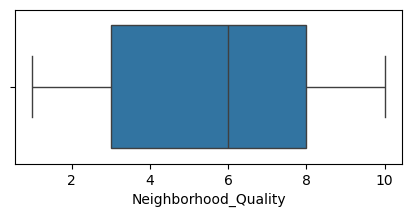

In [22]:
#Boxplot for Neighborhood_Quality
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Neighborhood_Quality')
plt.show()

**Bivariate Analysis**
- Scatter plot
- bar plot
- line plot

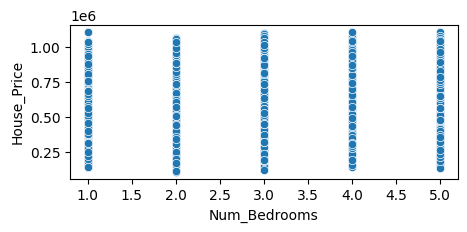

In [23]:
#Scatterplot
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Num_Bedrooms',y='House_Price')
plt.show()

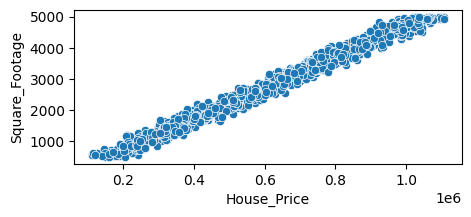

In [27]:
#scatterplot for square_footage and house price
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='House_Price',y='Square_Footage')
plt.show()

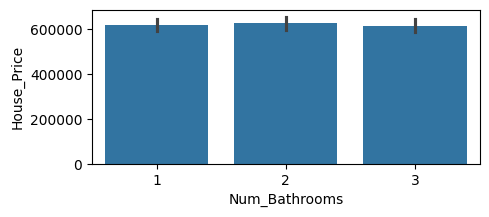

In [25]:
#bar plot for Num_Bathrooms and House_Price
plt.figure(figsize=(5,2))
sns.barplot(data,x='Num_Bathrooms',y='House_Price')
plt.show()

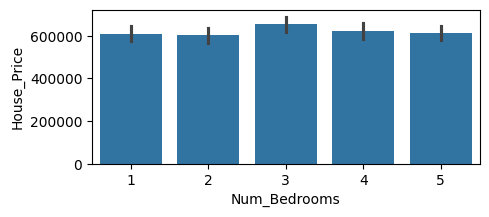

In [29]:
#bar plot for Num_Bedrooms and House_Price
plt.figure(figsize=(5,2))
sns.barplot(data,x='Num_Bedrooms',y='House_Price')
plt.show()

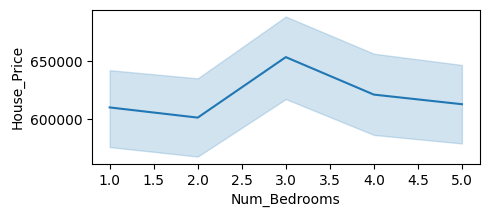

In [30]:
#lineplot for Num_Bedrooms and House_Price
plt.figure(figsize=(5,2))
sns.lineplot(data,x='Num_Bedrooms',y='House_Price')
plt.show()

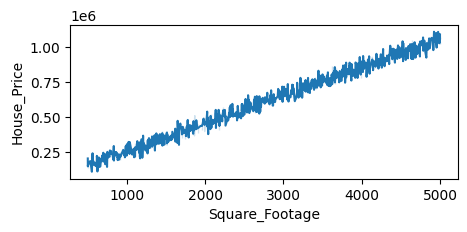

In [32]:
#lineplot for square_footage and house_price
plt.figure(figsize=(5,2))
sns.lineplot(data,x='Square_Footage',y='House_Price')
plt.show()

##**Correlation heatmap**

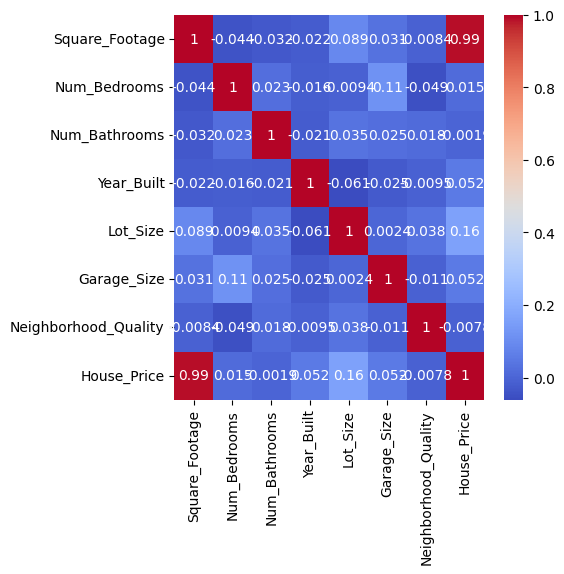

In [38]:
#heatmap
num_data = data.select_dtypes(include=np.number)

# Compute correlation matrix
corr = num_data.corr()

plt.figure(figsize=(5,5))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.show()

##**Detect and handle outliers**

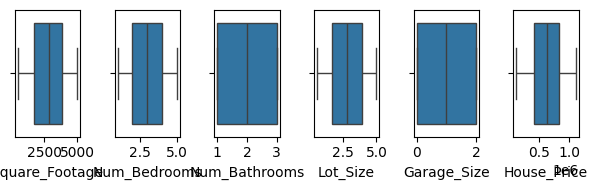

In [42]:
fig,ax=plt.subplots(1,6,figsize=(6,2))
sns.boxplot(data,x='Square_Footage',ax=ax[0])
sns.boxplot(data,x='Num_Bedrooms',ax=ax[1])
sns.boxplot(data,x='Num_Bathrooms',ax=ax[2])
sns.boxplot(data,x='Lot_Size',ax=ax[3])
sns.boxplot(data,x='Garage_Size',ax=ax[4])
sns.boxplot(data,x='House_Price',ax=ax[5])
plt.tight_layout()


**There are no outliers**

In [44]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


**There are no categorical values and does not require encoding**

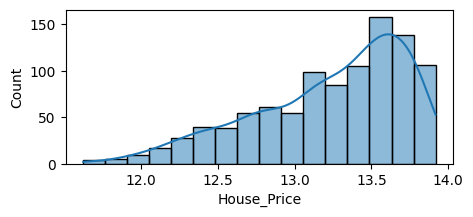

In [46]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='House_Price',kde=True)
plt.show()

In [51]:
data.loc[:,'House_Price']=np.log(data.loc[:,'House_Price'])

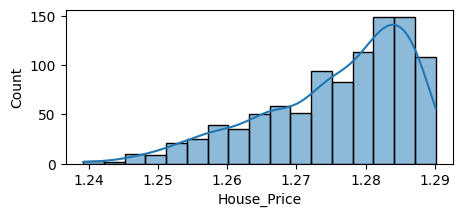

In [50]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='House_Price',kde=True)
plt.show()

##**Separate Features and Target Variable**

In [52]:
# Features
X = data.drop("House_Price", axis=1)
# Target
y = data["House_Price"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 7)
Target shape: (1000,)


In [53]:
#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
#Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


##**Linear Regression**

In [55]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [56]:
mae = mean_absolute_error(y_test, y_pred_lr)
print("MAE :", mae)

MAE : 0.0017141092884129137


In [57]:
mse = mean_squared_error(y_test, y_pred_lr)
print("MSE :", mse)

MSE : 4.640515545828515e-06


In [58]:
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 0.0021541855876011508


In [59]:
r2 = r2_score(y_test, y_pred_lr)
print("R2-Score:",r2)

R2-Score: 0.9326411069352285


In [60]:
n = len(y_test)
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R2:", adjusted_r2)

Adjusted R2: 0.9301853139589087


In [62]:
mape = mean_absolute_percentage_error(y_test, y_pred_lr)
print("MAPE:", mape)
print("MAPE (%):", mape * 100)

MAPE: 0.007135008736165693
MAPE (%): 0.7135008736165692


##**KNN Regression**

In [63]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [64]:
y_pred_knn = knn.predict(X_test)

In [65]:
mae = mean_absolute_error(y_test, y_pred_knn)
print("MAE:",mae)

MAE: 0.0022619104445076215


In [66]:
mse = mean_squared_error(y_test, y_pred_knn)
print("MSE:",mse)

MSE: 9.921445350150292e-06


In [67]:
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 0.003149832590813406


In [68]:
mape = mean_absolute_percentage_error(y_test, y_pred_knn)
print("MAPE (%):", mape * 100)

MAPE (%): 0.949895205006549


In [69]:
r2 = r2_score(y_test, y_pred_knn)
print("R2-score:",r2)

R2-score: 0.8559863511308569


In [70]:
n = len(y_test)
k = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R2:", adjusted_r2)

Adjusted R2: 0.850735853515836
